# Model Evaluation - XGBoost

Loads the best model from MLflow, evaluates on test set, tunes threshold interactively.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    f1_score, precision_score, recall_score
)
import mlflow
import mlflow.sklearn

from src.models.classifiers import XGBoostModel

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

from src.utils.config import load_config
from src.pipelines import ingest, preprocess

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

cfg = load_config()
print('Config loaded')

# adjust before running
SELECTED_RUN = 'xgboost__optuna_tuning'
RUN_VERSION = "V4"

/Users/sasiriakalanka/Large Documents/Projects/personal/fraud_detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Config loaded


## 1. Load best model from MLflow

In [2]:
mlflow.set_tracking_uri(cfg.mlflow.tracking_uri)
client = mlflow.tracking.MlflowClient()
exp    = client.get_experiment_by_name(cfg.mlflow.experiment_name)

runs = client.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string=f"tags.run_version = '{RUN_VERSION}'",
    order_by=['metrics.val_pr_auc DESC'],
    max_results=20,
)

run_df = pd.DataFrame([{
    'run_name'    : r.data.tags.get('mlflow.runName', r.info.run_id),
    'val_pr_auc'  : r.data.metrics.get('val_pr_auc', 0),
    'test_pr_auc' : r.data.metrics.get('test_pr_auc', 0),
    'val_f1'      : r.data.metrics.get('val_f1', 0),
    'test_f1'     : r.data.metrics.get('test_f1', 0),
    'run_id'      : r.info.run_id,
} for r in runs])

print('Top runs by val_pr_auc:')
run_df

Top runs by val_pr_auc:


,run_name,val_pr_auc,test_pr_auc,val_f1,test_f1,run_id
0,xgboost__optuna_tuning,0.872642,0.878879,0.000000,0.851282,5cf673d2d05e4db4996e5d5cf048b951
1,xgboost__class_weight,0.845862,0.878521,0.869565,0.845361,2d10010518b04e0b9ab3b312a41c4d8c
2,xgboost__none,0.841261,0.874244,0.873563,0.869565,a32558a948cc4e70ad3510502fb94f79
3,lightgbm__smote,0.837195,0.878948,0.833333,0.855721,2016e80caf1b477cb1085a2903166c43
4,random_forest__class_weight,0.833602,0.837706,0.854167,0.794258,c5cb1491c16f479185e99f6e0603fc60
5,xgboost__smote,0.831154,0.879958,0.784314,0.796296,2ab74b91da694aa6a23277959f72cd94
6,random_forest__none,0.826968,0.869194,0.876404,0.864865,7c1fec10f77b40ac8dd8e5203f5ea537
7,random_forest__smote,0.812352,0.823544,0.689076,0.666667,b2daf4c25b934673b6f0fd8d81409766
8,logistic_regression__none,0.760360,0.739074,0.750000,0.719101,67783b17d12e4a5bbedf2625ba0e0304
9,logistic_regression__smote,0.709678,0.705666,0.105521,0.104590,605a1a0560a942649ebae207a66bf699


In [3]:
selected = run_df[run_df['run_name'] == SELECTED_RUN].iloc[0]
run_id   = selected['run_id']
model    = mlflow.sklearn.load_model(f'runs:/{run_id}/model')

print(f'Loaded  : {SELECTED_RUN}')
print(f'val_pr_auc  : {selected["val_pr_auc"]:.4f}')
print(f'test_pr_auc : {selected["test_pr_auc"]:.4f}')

Loaded  : xgboost__optuna_tuning
val_pr_auc  : 0.8726
test_pr_auc : 0.8789


## 2. Get test set predictions

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test, feature_names = ingest.run(cfg)


X_train, X_val, X_test, y_train, y_val, y_test, _ = preprocess.run(
    cfg, XGBoostModel(cfg), 'none',
    X_train, X_val, X_test,
    y_train, y_val, y_test)

y_prob = model.predict_proba(X_test)[:, 1]

print(f'Test samples : {len(y_test):,}')
print(f'Fraud in test: {y_test.sum():,} ({y_test.mean()*100:.3f}%)')
print(f'Prob range   : {y_prob.min():.4f} -> {y_prob.max():.4f}')

2026-06-18 16:58:31 | INFO     | src.features.store | Feature store: loaded version='latest' | shape=(284807, 31)
2026-06-18 16:58:31 | INFO     | src.pipelines.ingest | Validation passed - 284,807 rows, 31 cols
2026-06-18 16:58:31 | INFO     | src.pipelines.ingest | Fraud rate: 0.173%  (492 fraud / 284,315 legit)
2026-06-18 16:58:31 | INFO     | src.pipelines.ingest | Split -> train: 199,364 | val: 28,481 | test: 56,962
2026-06-18 16:58:31 | INFO     | src.pipelines.preprocess | Preprocessing - strategy: none
Test samples : 56,962
Fraud in test: 98 (0.172%)
Prob range   : 0.0000 -> 1.0000


## 3. PR curve

Shows precision vs recall at every possible threshold.
The area under this curve (PR-AUC) is our primary metric.

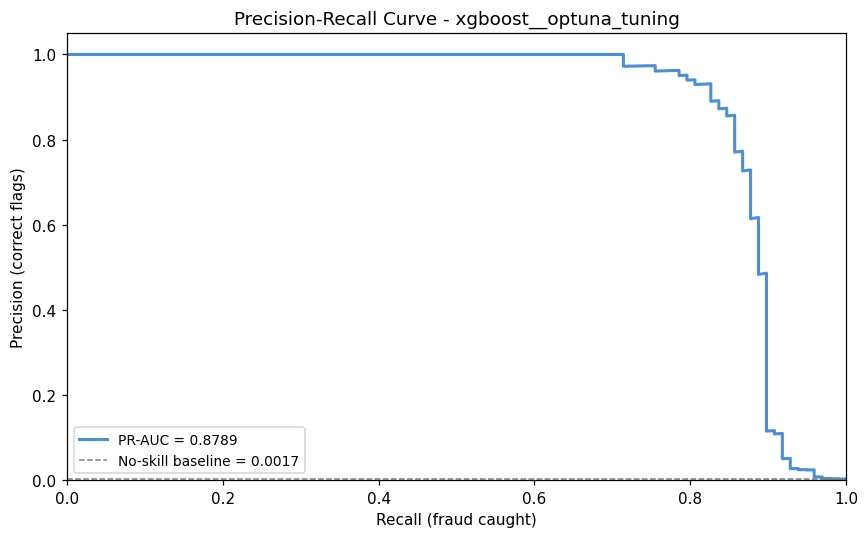

PR-AUC: 0.8789


In [5]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall, precision, color='#4A90D9', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
ax.axhline(y_test.mean(), color='gray', ls='--', lw=1,
           label=f'No-skill baseline = {y_test.mean():.4f}')
ax.set(xlabel='Recall (fraud caught)', ylabel='Precision (correct flags)',
       title=f'Precision-Recall Curve - {SELECTED_RUN}',
       xlim=[0,1], ylim=[0,1.05])
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'PR-AUC: {pr_auc:.4f}')

## 4. Threshold analysis

Sweep all thresholds - find where F1 peaks.
This is NOT retraining. Model weights are frozen.

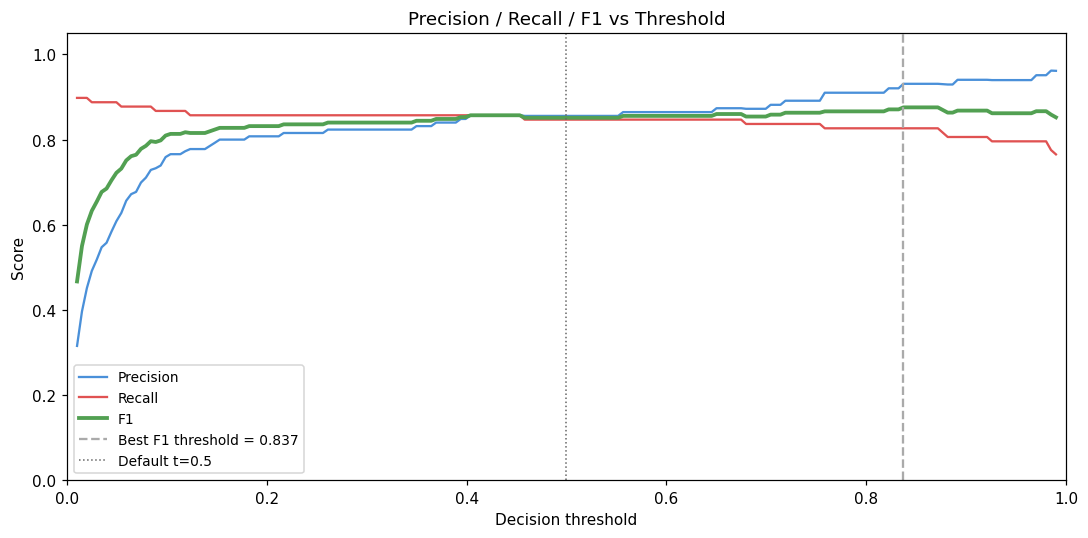

Best threshold : 0.837
At best threshold:
  Precision : 0.931
  Recall    : 0.827
  F1        : 0.876


In [6]:
sweep = np.linspace(0.01, 0.99, 200)
precisions, recalls, f1s = [], [], []

for t in sweep:
    preds = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    f1s.append(f1_score(y_test, preds, zero_division=0))

best_idx = np.argmax(f1s)
BEST_T   = float(sweep[best_idx])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep, precisions, '#4A90D9', label='Precision', lw=1.5)
ax.plot(sweep, recalls,    '#E05252', label='Recall',    lw=1.5)
ax.plot(sweep, f1s,        '#52A052', label='F1',        lw=2.5)
ax.axvline(BEST_T, color='#aaa', ls='--', lw=1.5,
           label=f'Best F1 threshold = {BEST_T:.3f}')
ax.axvline(0.5, color='#666', ls=':', lw=1, label='Default t=0.5')
ax.set(xlabel='Decision threshold', ylabel='Score',
       title='Precision / Recall / F1 vs Threshold',
       xlim=[0,1], ylim=[0,1.05])
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Best threshold : {BEST_T:.3f}')
print(f'At best threshold:')
print(f'  Precision : {precisions[best_idx]:.3f}')
print(f'  Recall    : {recalls[best_idx]:.3f}')
print(f'  F1        : {f1s[best_idx]:.3f}')

## 5. Custom threshold dashboard

Change `CUSTOM_T` below and rerun this cell.
Use this to make the business decision - higher recall catches more fraud, lower precision means more false alarms.

In [7]:
CUSTOM_T = BEST_T   # change this manually e.g. 0.3 for higher recall

preds = (y_prob >= CUSTOM_T).astype(int)

print(f'Threshold : {CUSTOM_T}')
print(f'Flagged   : {preds.sum():,} / {len(preds):,} transactions')
print()
print(classification_report(y_test, preds, target_names=['Legit', 'Fraud']))

Threshold : 0.8373366834170854
Flagged   : 87 / 56,962 transactions

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.93      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



## 6. Confusion matrix at chosen threshold

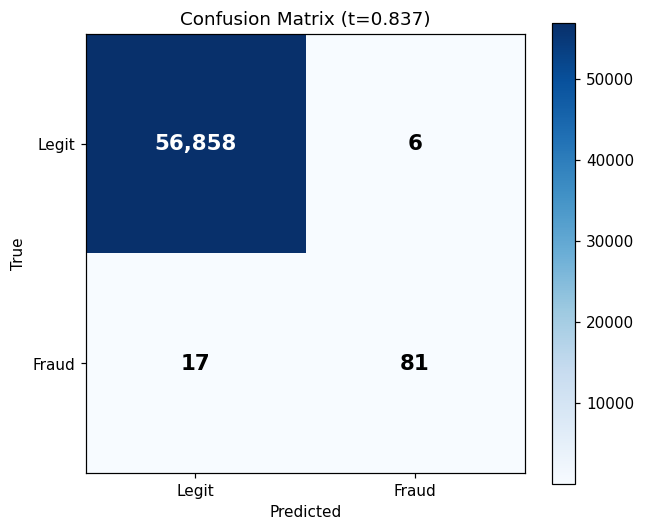

True Positives  (fraud caught)    : 81
False Negatives (fraud missed)    : 17
False Positives (legit flagged)   : 6
True Negatives  (legit cleared)   : 56,858


In [8]:
cm = confusion_matrix(y_test, (y_prob >= CUSTOM_T).astype(int))
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set(xticks=[0,1], yticks=[0,1],
       xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'],
       xlabel='Predicted', ylabel='True',
       title=f'Confusion Matrix (t={CUSTOM_T:.3f})')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print(f'True Positives  (fraud caught)    : {tp:,}')
print(f'False Negatives (fraud missed)    : {fn:,}')
print(f'False Positives (legit flagged)   : {fp:,}')
print(f'True Negatives  (legit cleared)   : {tn:,}')

## 7. Log final threshold to MLflow

In [9]:
with mlflow.start_run(run_id=run_id):
    mlflow.log_metrics({
        'best_threshold'   : CUSTOM_T,
        'test_pr_auc_final': pr_auc,
    })

print(f'Logged threshold {CUSTOM_T:.3f} to MLflow run: {SELECTED_RUN}')

🏃 View run xgboost__optuna_tuning at: http://127.0.0.1:5000/#/experiments/1/runs/5cf673d2d05e4db4996e5d5cf048b951
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Logged threshold 0.837 to MLflow run: xgboost__optuna_tuning
